### **Initializing**
Environemnts and External Libraries

---

*   Google Query & Colab utilites
*   Common Data-Sci: pandas, matplot etc.



In [ ]:
import os
%load_ext google.colab.data_table
from google.colab.data_table import DataTable
from google.colab import auth
from google.cloud.bigquery import magics
from google.cloud import bigquery
import scipy
import matplotlib.pyplot as plt
import pandas as pd

!pip install amsterdamumcdb
import amsterdamumcdb as adb

#Changing Default plot-styles
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams["figure.dpi"] = 144

DataTable.max_rows = 30000
DataTable.max_columns = 50

The google.colab.data_table extension is already loaded. To reload it, use:
  %reload_ext google.colab.data_table


**Account authentication & Configs**

*   Using Ivelin's project_id at `"PROJECT_ID"`
*   Account Authentcation




In [ ]:
PROJECT_ID = ""
DATASET_PROJECT_ID = 'amsterdamumcdb'
DATASET_ID = 'version1_5_0'
LOCATION = 'eu'


config_gbq = {'query':
          {'defaultDataset': {
              "datasetId": DATASET_ID,
              "projectId": DATASET_PROJECT_ID
              },
           'Location': LOCATION}
           }


os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
auth.authenticate_user()

Default_Conf = bigquery.job.QueryJobConfig(default_dataset=DATASET_PROJECT_ID + "." + DATASET_ID)
magics.context.default_query_job_config = Default_Conf

Data_Query = bigquery.job.QueryJobConfig()
Request = bigquery.Client(project=PROJECT_ID,location=LOCATION, default_query_job_config=Default_Conf)

print("Set-up Successful :)")

Set-up Successful :)


In [ ]:
dictionary = adb.get_dictionary()
dictionary = dictionary.convert_dtypes()
dictionary

,concept_id,concept_name,domain_id,concept_class_id,vocabulary_id,concept_code,source_vocabulary_id,source_code,source_code_description,source_frequency,source_frequency_validated,mapping_status,equivalence
0,8532,FEMALE,Gender,Gender,Gender,F,AUMC Gender,Vrouw,Vrouw,7875,7875,APPROVED,EQUAL
1,8507,MALE,Gender,Gender,Gender,M,AUMC Gender,Man,Man,14735,14735,APPROVED,EQUAL
2,581476,Home Visit,Visit,Visit,Visit,OMOP4822459,AUMC Origin,Huis,Huis,85,85,APPROVED,EQUAL
3,581383,Inpatient Cardiac Care Facility,Visit,Visit,CMS Place of Service,OMOP4822038,AUMC Origin,CCU/IC zelfde ziekenhuis,CCU/IC zelfde ziekenhuis,296,296,APPROVED,EQUAL
4,8870,Emergency Room - Hospital,Visit,Visit,CMS Place of Service,23,AUMC Origin,Eerste Hulp afdeling zelfde ziekenhuis,Eerste Hulp afdeling zelfde ziekenhuis,2661,2661,APPROVED,EQUAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10620,37079369,Supplemental result,Meas Value,Answer,LOINC,LA29938-0,AUMC Specimen Source,11646-ZIE-OPM,ZIE-OPM,812,812,APPROVED,EQUIVALENT
10621,36210399,Not specified,Meas Value,Answer,LOINC,LA27211-4,AUMC Specimen Source,11646-0,0,1,1,APPROVED,EQUIVALENT
10622,4302933,Pleural fluid specimen,Specimen,Specimen,SNOMED,418564007,AUMC Specimen Source,11646-Vocht thoraxdrain,Vocht thoraxdrain,1,1,APPROVED,EQUAL
10623,45879739,No sample received,Meas Value,Answer,LOINC,LA12433-1,AUMC Specimen Source,11646-Niet afgenomen door afd/arts,Niet afgenomen door afd/arts,99,99,APPROVED,EQUIVALENT


In [ ]:

Data_set = Request.query('''WITH Patient_Gender AS (
    SELECT
        o.person_id,
        CASE
            WHEN o.value_as_concept_id = 8507 THEN 'Male'
            WHEN o.value_as_concept_id = 8532 THEN 'Female'
            ELSE 'Unknown'
        END AS gender
    FROM
        observation o
    WHERE
        o.observation_concept_id = 4083588 -- Patient sex concept ID
        AND o.value_as_concept_id IN (8532, 8507) -- Female and Male
        AND o.provider_id IS NOT NULL -- Satisfy partition elimination requirement
),

Patient_Weight AS (
    SELECT
        person_id,
        value_as_number AS weight
    FROM
        measurement
    WHERE
        provider_id IS NULL
        AND measurement_concept_id = 3013762 -- Body weight Measured
),

LOS_Data AS (
    SELECT
        v.person_id,
        v.visit_occurrence_id,
        SUM(TIMESTAMP_DIFF(visit_end_datetime, visit_start_datetime, HOUR)) / 24.0 AS los_days,
        EXTRACT(YEAR FROM visit_start_datetime) - year_of_birth AS age
    FROM
        visit_occurrence v
    INNER JOIN
        person o ON v.person_id = o.person_id
    LEFT JOIN
        concept c ON o.gender_concept_id = c.concept_id
    GROUP BY
        v.person_id, v.visit_occurrence_id, age
    HAVING
        los_days <= 24

),

Ranked_Measurements AS (
    SELECT
        m.person_id,
        m.measurement_datetime,
        m.measurement_source_value,
        CASE WHEN specimen_concept_id = 4047496 THEN 'arterial' END AS specimen,
        c2.concept_name,
        m.value_as_number,
        ROW_NUMBER() OVER (PARTITION BY c2.concept_id ORDER BY m.measurement_datetime) AS rn
    FROM
        measurement m
    INNER JOIN
        concept c2 ON m.measurement_concept_id = c2.concept_id
    INNER JOIN
        specimen s ON m.person_id = s.person_id
        AND m.measurement_datetime = s.specimen_datetime
        AND s.specimen_concept_id = 4047496
    WHERE
        NOT m.provider_id IS NULL -- ignore unvalidated device data
        AND m.measurement_type_concept_id = 32856 -- Lab
        AND c2.concept_id IN (
            3010421, -- pH of Blood
            3027315, -- pO2 Oxygen [Partial pressure] in Blood
            3013290, -- pCO2 Carbon dioxide [Partial pressure] in Blood
            42869608, -- SaO2 Oxygen saturation [Pure mass fraction] in Blood
            3006576, -- Bicarbonate [Moles/volume] in blood
            3000285, -- Sodium [Moles/volume] in Blood
            3005456, -- Potassium [Moles/volume] in Blood
            3047181, -- Lactate [Moles/volume] in Blood
            3018572, -- Chloride [Moles/volume] in Blood
            3003458, -- Phosphate [Moles/volume] in Serum or Plasma
            3024561, -- Albumin [Mass/volume] in Serum or Plasma
            3015377, -- Calcium [Moles/volume] in Serum or Plasma
            3012095, -- Magnesium [Moles/volume] in Serum or Plasma
            40762351 -- Hemoglobin [Moles/volume] in Blood
        )
),

Death_Data AS (
    SELECT
        person_id,
        1 AS deceased,
        death_date
    FROM
        death

)

SELECT
    pg.person_id,
    pg.gender,
    pw.weight,
    ld.visit_occurrence_id,
    ld.los_days,
    ld.age,
    rm.measurement_datetime,
    rm.measurement_source_value,
    rm.specimen,
    rm.concept_name,
    rm.value_as_number,
    dd.death_date,
    dd.deceased
FROM
    Patient_Gender pg
INNER JOIN
    Patient_Weight pw ON pg.person_id = pw.person_id
INNER JOIN
    LOS_Data ld ON pg.person_id = ld.person_id
INNER JOIN
    Ranked_Measurements rm ON pg.person_id = rm.person_id
LEFT JOIN
    Death_Data dd ON pg.person_id = dd.person_id

''').to_dataframe()


In [ ]:
Data_set.info()
Data_set.shape[0]
Data_set.describe()
Data_set.head()

<class 'pandas.core.frame.DataFrame'>
Index: 10683486 entries, 1265990 to 9717406
Data columns (total 13 columns):
 #   Column                    Dtype              
---  ------                    -----              
 0   person_id                 Int64              
 1   gender                    object             
 2   weight                    object             
 3   visit_occurrence_id       Int64              
 4   los_days                  float64            
 5   age                       Int64              
 6   measurement_datetime      datetime64[us, UTC]
 7   measurement_source_value  object             
 8   specimen                  object             
 9   concept_name              object             
 10  value_as_number           object             
 11  death_date                dbdate             
 12  deceased                  Int64              
dtypes: Int64(4), datetime64[us, UTC](1), dbdate(1), float64(1), object(6)
memory usage: 1.2+ GB


,person_id,gender,weight,visit_occurrence_id,los_days,age,measurement_datetime,measurement_source_value,specimen,concept_name,value_as_number,death_date,deceased
1265990,7,Male,75.00000000000000000000000000000000000000,7,1.708333,75,2012-12-31 14:00:00+00:00,Hb(v.Bgs) (bloed),arterial,Hemoglobin [Moles/volume] in Blood,6.50000000000000000000000000000000000000,NaT,<NA>
2455316,7,Male,75.00000000000000000000000000000000000000,7,1.708333,75,2012-12-31 14:00:00+00:00,O2-Saturatie (bloed),arterial,Oxygen saturation [Pure mass fraction] in Blood,0.99000001000000000000000000000000000000,NaT,<NA>
4280635,7,Male,75.00000000000000000000000000000000000000,7,1.708333,75,2012-12-31 14:00:00+00:00,Cl (onv.ISE) (bloed),arterial,Chloride [Moles/volume] in Blood,106.00000000000000000000000000000000000000,NaT,<NA>
4471286,7,Male,75.00000000000000000000000000000000000000,7,1.708333,75,2012-12-31 14:00:00+00:00,pCO2 (bloed),arterial,Carbon dioxide [Partial pressure] in Blood,42.00000000000000000000000000000000000000,NaT,<NA>
4483181,7,Male,75.00000000000000000000000000000000000000,7,1.708333,75,2012-12-31 14:00:00+00:00,PO2 (bloed),arterial,Oxygen [Partial pressure] in Blood,189.00000000000000000000000000000000000000,NaT,<NA>


In [ ]:
from google.colab import files
uploaded = files.upload() # Opens a browser to import a .py file


Saving MedCoders.py to MedCoders (4).py


# Reformating the dataset by:

1.   All measurements are held in a single column
2.   All measurements are in continuous timestamp
3.   All 'NaN' rows are droped, not all labs have good frequency.


In [ ]:
Data_set = Data_set.sort_values(by=['person_id', 'measurement_datetime'])
initial_lab_measurements = Data_set.groupby(['person_id', 'concept_name']).first().reset_index()
pivoted_data = initial_lab_measurements.pivot_table(index='person_id',
                                                    columns='concept_name',
                                                    values='value_as_number')
del initial_lab_measurements

pivoted_data = pivoted_data.reset_index()
pivoted_data = pivoted_data.dropna()
#del Data_set Saving RAM... I had a few crashes :/

In [ ]:
pivoted_data.head()

concept_name,person_id,Albumin [Mass/volume] in Serum or Plasma,Bicarbonate [Moles/volume] in Blood,Calcium [Moles/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Blood,Chloride [Moles/volume] in Blood,Hemoglobin [Moles/volume] in Blood,Lactate [Moles/volume] in Blood,Magnesium [Moles/volume] in Serum or Plasma,Oxygen [Partial pressure] in Blood,Oxygen saturation [Pure mass fraction] in Blood,Phosphate [Moles/volume] in Serum or Plasma,Potassium [Moles/volume] in Blood,Sodium [Moles/volume] in Blood,pH of Blood
0,7,26.0,25.5,1.8,42.0,106.0,6.5,1.3,0.57,189.0,0.99,1.29,3.7,143.0,7.4
9,122,17.0,20.299999,1.77,32.0,99.0,6.0,2.9,0.38,86.0,0.98,0.94,3.7,130.0,7.42
11,188,33.0,19.1,2.35,34.0,107.0,7.9,1.9,1.04,116.0,0.98,1.31,4.1,136.0,7.37
19,268,27.0,25.5,2.28,41.0,107.0,8.3,1.0,1.14,391.0,0.99,0.74,4.0,136.0,7.41
20,289,31.0,23.0,2.13,37.0,107.0,8.8,1.2,0.71,97.0,0.98,0.63,3.8,142.0,7.41


# Appending patient's ID with phenotype diagnosis from MedCoders algorithms

In [189]:
# Not very pragmatic implementation
# I was in a hurry :/

from MedCoders import Henderson_Hasselbalch
from MedCoders import Stewart_analysis
from MedCoders import Physiological_ACID_Based


def solve_HH(DataSet):
  HH_phenotyper = Henderson_Hasselbalch()
  solution = dict()

  for index, row in DataSet.iterrows():
    HH_args = {"measured_ph":row['pH of Blood'],
               "pco2": row['Carbon dioxide [Partial pressure] in Blood'],
               "hco3": row['Bicarbonate [Moles/volume] in Blood']}
    HH_phenotyper.run(HH_args)
    solution[row['person_id']] = HH_phenotyper.Get()
  return solution




def solve_Stew(DataSet):
  solution = dict()
  Stew_phenotyper = Stewart_analysis()

  for index, row in DataSet.iterrows():
    Steward_Args = {"na": row['Sodium [Moles/volume] in Blood'], "k": row['Potassium [Moles/volume] in Blood'],
                    "ca": row['Calcium [Moles/volume] in Serum or Plasma'], "mg": row['Magnesium [Moles/volume] in Serum or Plasma'],
                    "cl":row['Chloride [Moles/volume] in Blood'], "Lactate": row['Lactate [Moles/volume] in Blood'], "other_anitons": 0.0,
                    "albumin": row['Albumin [Mass/volume] in Serum or Plasma'], "Phosphate": row['Phosphate [Moles/volume] in Serum or Plasma'],
                    "ph":row['pH of Blood'], "hco3": row['Bicarbonate [Moles/volume] in Blood'], "pco2": row['Carbon dioxide [Partial pressure] in Blood']}
    #print(Steward_Args)
    Stew_phenotyper.run(Steward_Args)
    solution[row['person_id']] = Stew_phenotyper.Get()
  return solution




def solve_Physiol(DataSet):
  solution = dict()
  Physio_phenotyper = Physiological_ACID_Based()
  for index, row in DataSet.iterrows():
    label = Physio_phenotyper.classify_acid_base_disorder(row['pH of Blood'],
                          row['Bicarbonate [Moles/volume] in Blood'],
                          row['Carbon dioxide [Partial pressure] in Blood'],
                          row['Sodium [Moles/volume] in Blood'],
                          row['Potassium [Moles/volume] in Blood'],
                          row['Chloride [Moles/volume] in Blood'])

    solution[row['person_id']] = label
  return solution

# Clustering patients into phenotype clusters

In [190]:
cluster_Physiol = solve_Physiol(pivoted_data)
cluster_Stew = solve_Stew(pivoted_data)
cluster_HH = solve_HH(pivoted_data)

# Analysing Mortality Rate per algorithm clusters

In [204]:
import pandas as pd
import matplotlib.pyplot as plt

def Mortality_Rate(cluster, data_set):
    phenotype_occurrence = {}
    mortality_rate = {}

    for key, value in cluster.items():
        # Count phenotype occurrences
        if value in phenotype_occurrence:
            phenotype_occurrence[value] += 1
        else:
            phenotype_occurrence[value] = 1

        # Count mortality
        if not pd.isna(data_set.at[key, "deceased"]):
            if data_set.at[key, "deceased"] == 1:
                if value in mortality_rate:
                    mortality_rate[value] += 1
                else:
                    mortality_rate[value] = 1
    print(phenotype_occurrence)
    print(mortality_rate)

    print("<----------------------------------------->\n\n")
    for cluster_num, count in mortality_rate.items():
        mortality_rate[cluster_num] = (count / phenotype_occurrence[cluster_num]) * 100

    cluster_numbers = list(mortality_rate.keys())
    mortality_rates = list(mortality_rate.values())


    plt.figure(figsize=(8, 6))
    plt.bar(cluster_numbers, mortality_rates, color='skyblue', edgecolor='black')
    plt.xlabel("Cluster Phenotype")
    plt.ylabel("Mortality Rate (%)")
    plt.title("Mortality Rates by Patient Clusters")
    plt.xticks(rotation=40)  # Rotate x-axis labels for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return phenotype_occurrence, mortality_rate


# Physiological ACID Based Phenotypes

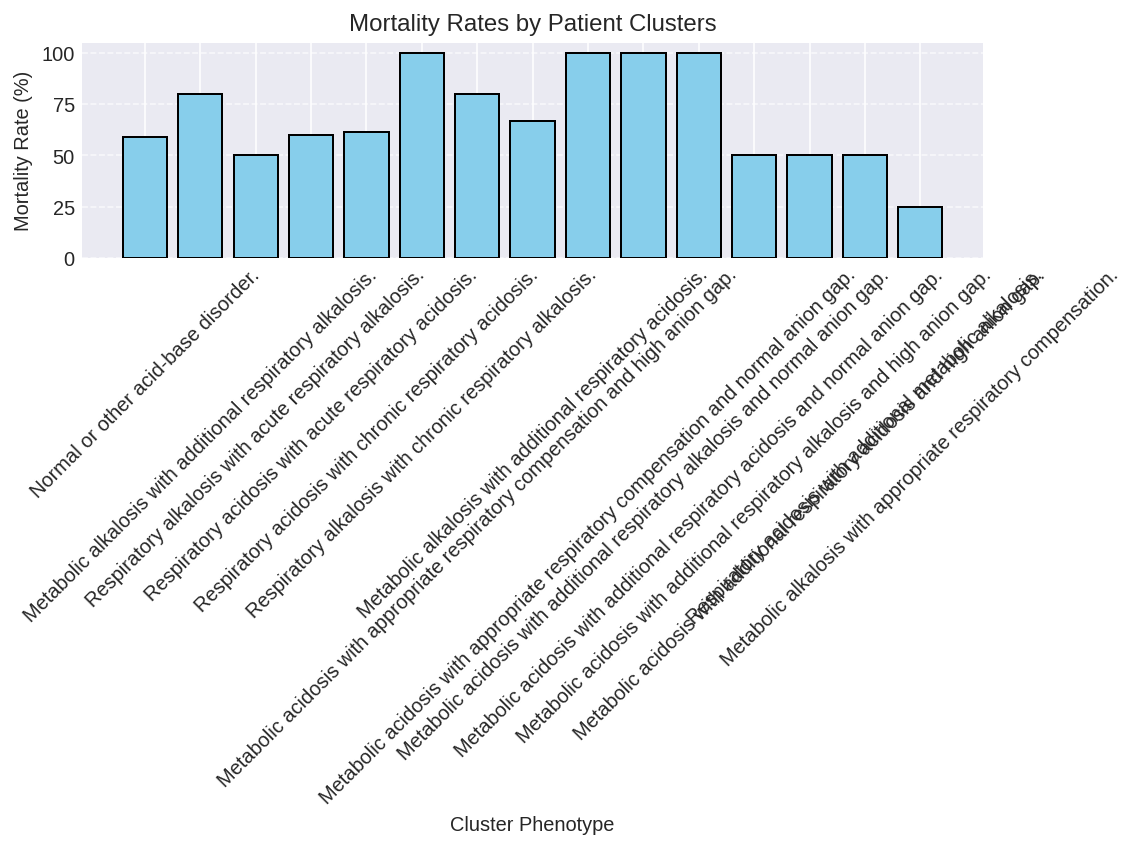

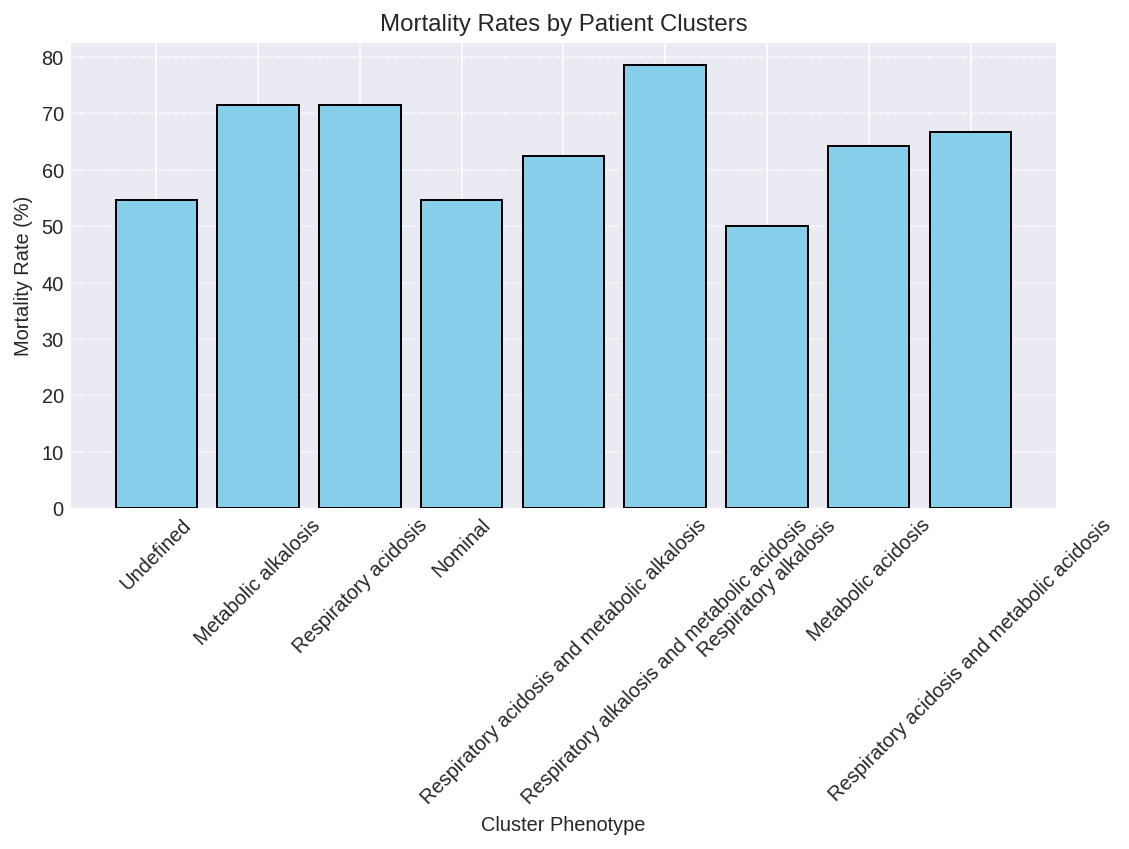

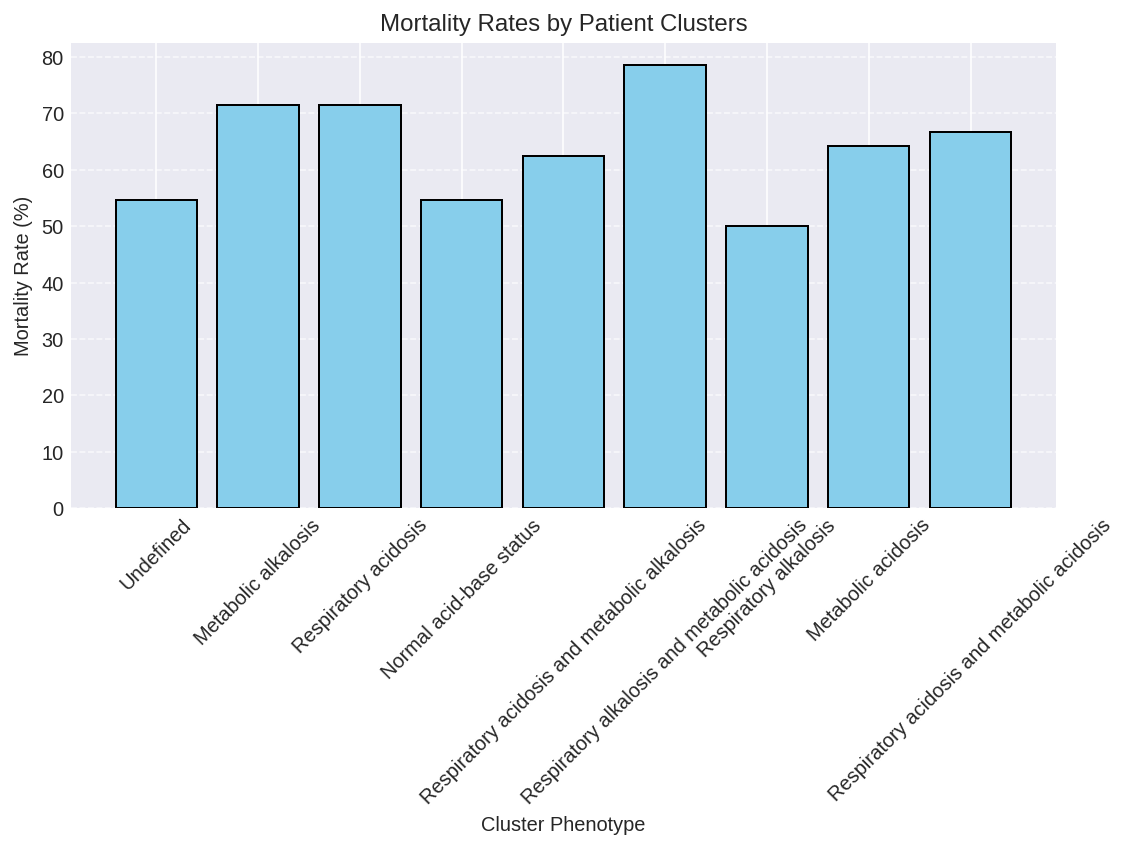

({'Normal acid-base status': 64,
  'Undefined': 64,
  'Respiratory alkalosis': 6,
  'Metabolic alkalosis': 7,
  'Respiratory acidosis': 14,
  'Respiratory acidosis and metabolic alkalosis': 8,
  'Respiratory alkalosis and metabolic acidosis': 14,
  'Metabolic acidosis': 14,
  'Respiratory acidosis and metabolic acidosis': 3},
 {'Undefined': 54.6875,
  'Metabolic alkalosis': 71.42857142857143,
  'Respiratory acidosis': 71.42857142857143,
  'Normal acid-base status': 54.6875,
  'Respiratory acidosis and metabolic alkalosis': 62.5,
  'Respiratory alkalosis and metabolic acidosis': 78.57142857142857,
  'Respiratory alkalosis': 50.0,
  'Metabolic acidosis': 64.28571428571429,
  'Respiratory acidosis and metabolic acidosis': 66.66666666666666})

In [208]:
Mortality_Rate(cluster_Physiol,Data_set)
Mortality_Rate(cluster_HH,Data_set)
Mortality_Rate(cluster_Stew,Data_set)